In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from src.config import PROCESSED_DATA_PATH

In [4]:
df = pd.read_csv(PROCESSED_DATA_PATH)

In [7]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,9600.0,36 months,12.99,323.42,C,C1,NaN,RENT,21900.0,Verified,...,1.0,4509.0,38.9,20.0,Individual,687.0,0.438356,0.014768,13.081451,0
1,4000.0,36 months,6.68,122.93,A,A3,4.0,MORTGAGE,83000.0,Not Verified,...,0.0,1564.0,17.2,25.0,Individual,782.0,0.048193,0.001481,11.581109,0
2,6025.0,36 months,10.91,197.00,B,B4,10.0,RENT,52000.0,Not Verified,...,0.0,2706.0,12.8,25.0,Individual,742.0,0.115865,0.003788,12.501027,0
3,20000.0,36 months,9.49,640.57,B,B2,10.0,MORTGAGE,100000.0,Not Verified,...,0.0,20440.0,56.3,32.0,Individual,697.0,0.200000,0.006406,26.001369,0
4,1000.0,36 months,8.18,31.42,B,B1,NaN,RENT,23000.0,Verified,...,0.0,3237.0,77.1,38.0,Individual,682.0,0.043478,0.001366,28.580424,0


In [8]:
df.shape

(71348, 24)

In [9]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [10]:
df['term'] = df['term'].str.replace(' months', '').astype(int)

In [11]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,9600.0,36,12.99,323.42,C,C1,NaN,RENT,21900.0,Verified,...,1.0,4509.0,38.9,20.0,Individual,687.0,0.438356,0.014768,13.081451,0
1,4000.0,36,6.68,122.93,A,A3,4.0,MORTGAGE,83000.0,Not Verified,...,0.0,1564.0,17.2,25.0,Individual,782.0,0.048193,0.001481,11.581109,0
2,6025.0,36,10.91,197.00,B,B4,10.0,RENT,52000.0,Not Verified,...,0.0,2706.0,12.8,25.0,Individual,742.0,0.115865,0.003788,12.501027,0
3,20000.0,36,9.49,640.57,B,B2,10.0,MORTGAGE,100000.0,Not Verified,...,0.0,20440.0,56.3,32.0,Individual,697.0,0.200000,0.006406,26.001369,0
4,1000.0,36,8.18,31.42,B,B1,NaN,RENT,23000.0,Verified,...,0.0,3237.0,77.1,38.0,Individual,682.0,0.043478,0.001366,28.580424,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71348 entries, 0 to 71347
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   loan_amnt              71348 non-null  float64
 1   term                   71348 non-null  int32  
 2   int_rate               71348 non-null  float64
 3   installment            71348 non-null  float64
 4   grade                  71348 non-null  object 
 5   sub_grade              71348 non-null  object 
 6   emp_length             67187 non-null  float64
 7   home_ownership         71348 non-null  object 
 8   annual_inc             71348 non-null  float64
 9   verification_status    71348 non-null  object 
 10  purpose                71348 non-null  object 
 11  dti                    71324 non-null  float64
 12  delinq_2yrs            71348 non-null  float64
 13  open_acc               71348 non-null  float64
 14  pub_rec                71348 non-null  float64
 15  re

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,71348.0,14394.848839,8729.290410,1000.000000,7850.000000,12000.000000,20000.000000,4.000000e+04
term,71348.0,41.806582,10.278281,36.000000,36.000000,36.000000,36.000000,6.000000e+01
int_rate,71348.0,13.279731,4.783285,5.310000,9.750000,12.790000,16.020000,3.099000e+01
installment,71348.0,437.459023,262.154873,21.740000,247.970000,373.220000,578.680000,1.717630e+03
emp_length,67187.0,5.954798,3.694838,0.000000,2.000000,6.000000,10.000000,1.000000e+01
annual_inc,71348.0,76158.117381,79740.005411,0.000000,45500.000000,65000.000000,90000.000000,1.099920e+07
dti,71324.0,18.278028,11.481897,0.000000,11.737500,17.660000,24.050000,9.990000e+02
delinq_2yrs,71348.0,0.317136,0.864510,0.000000,0.000000,0.000000,0.000000,2.000000e+01
open_acc,71348.0,11.599120,5.464398,1.000000,8.000000,11.000000,14.000000,6.400000e+01
pub_rec,71348.0,0.218142,0.652375,0.000000,0.000000,0.000000,0.000000,6.100000e+01


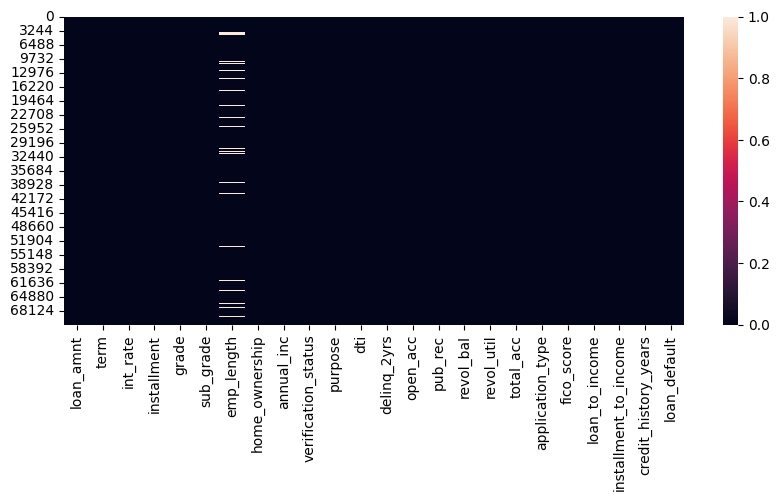

In [14]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull())
plt.show()

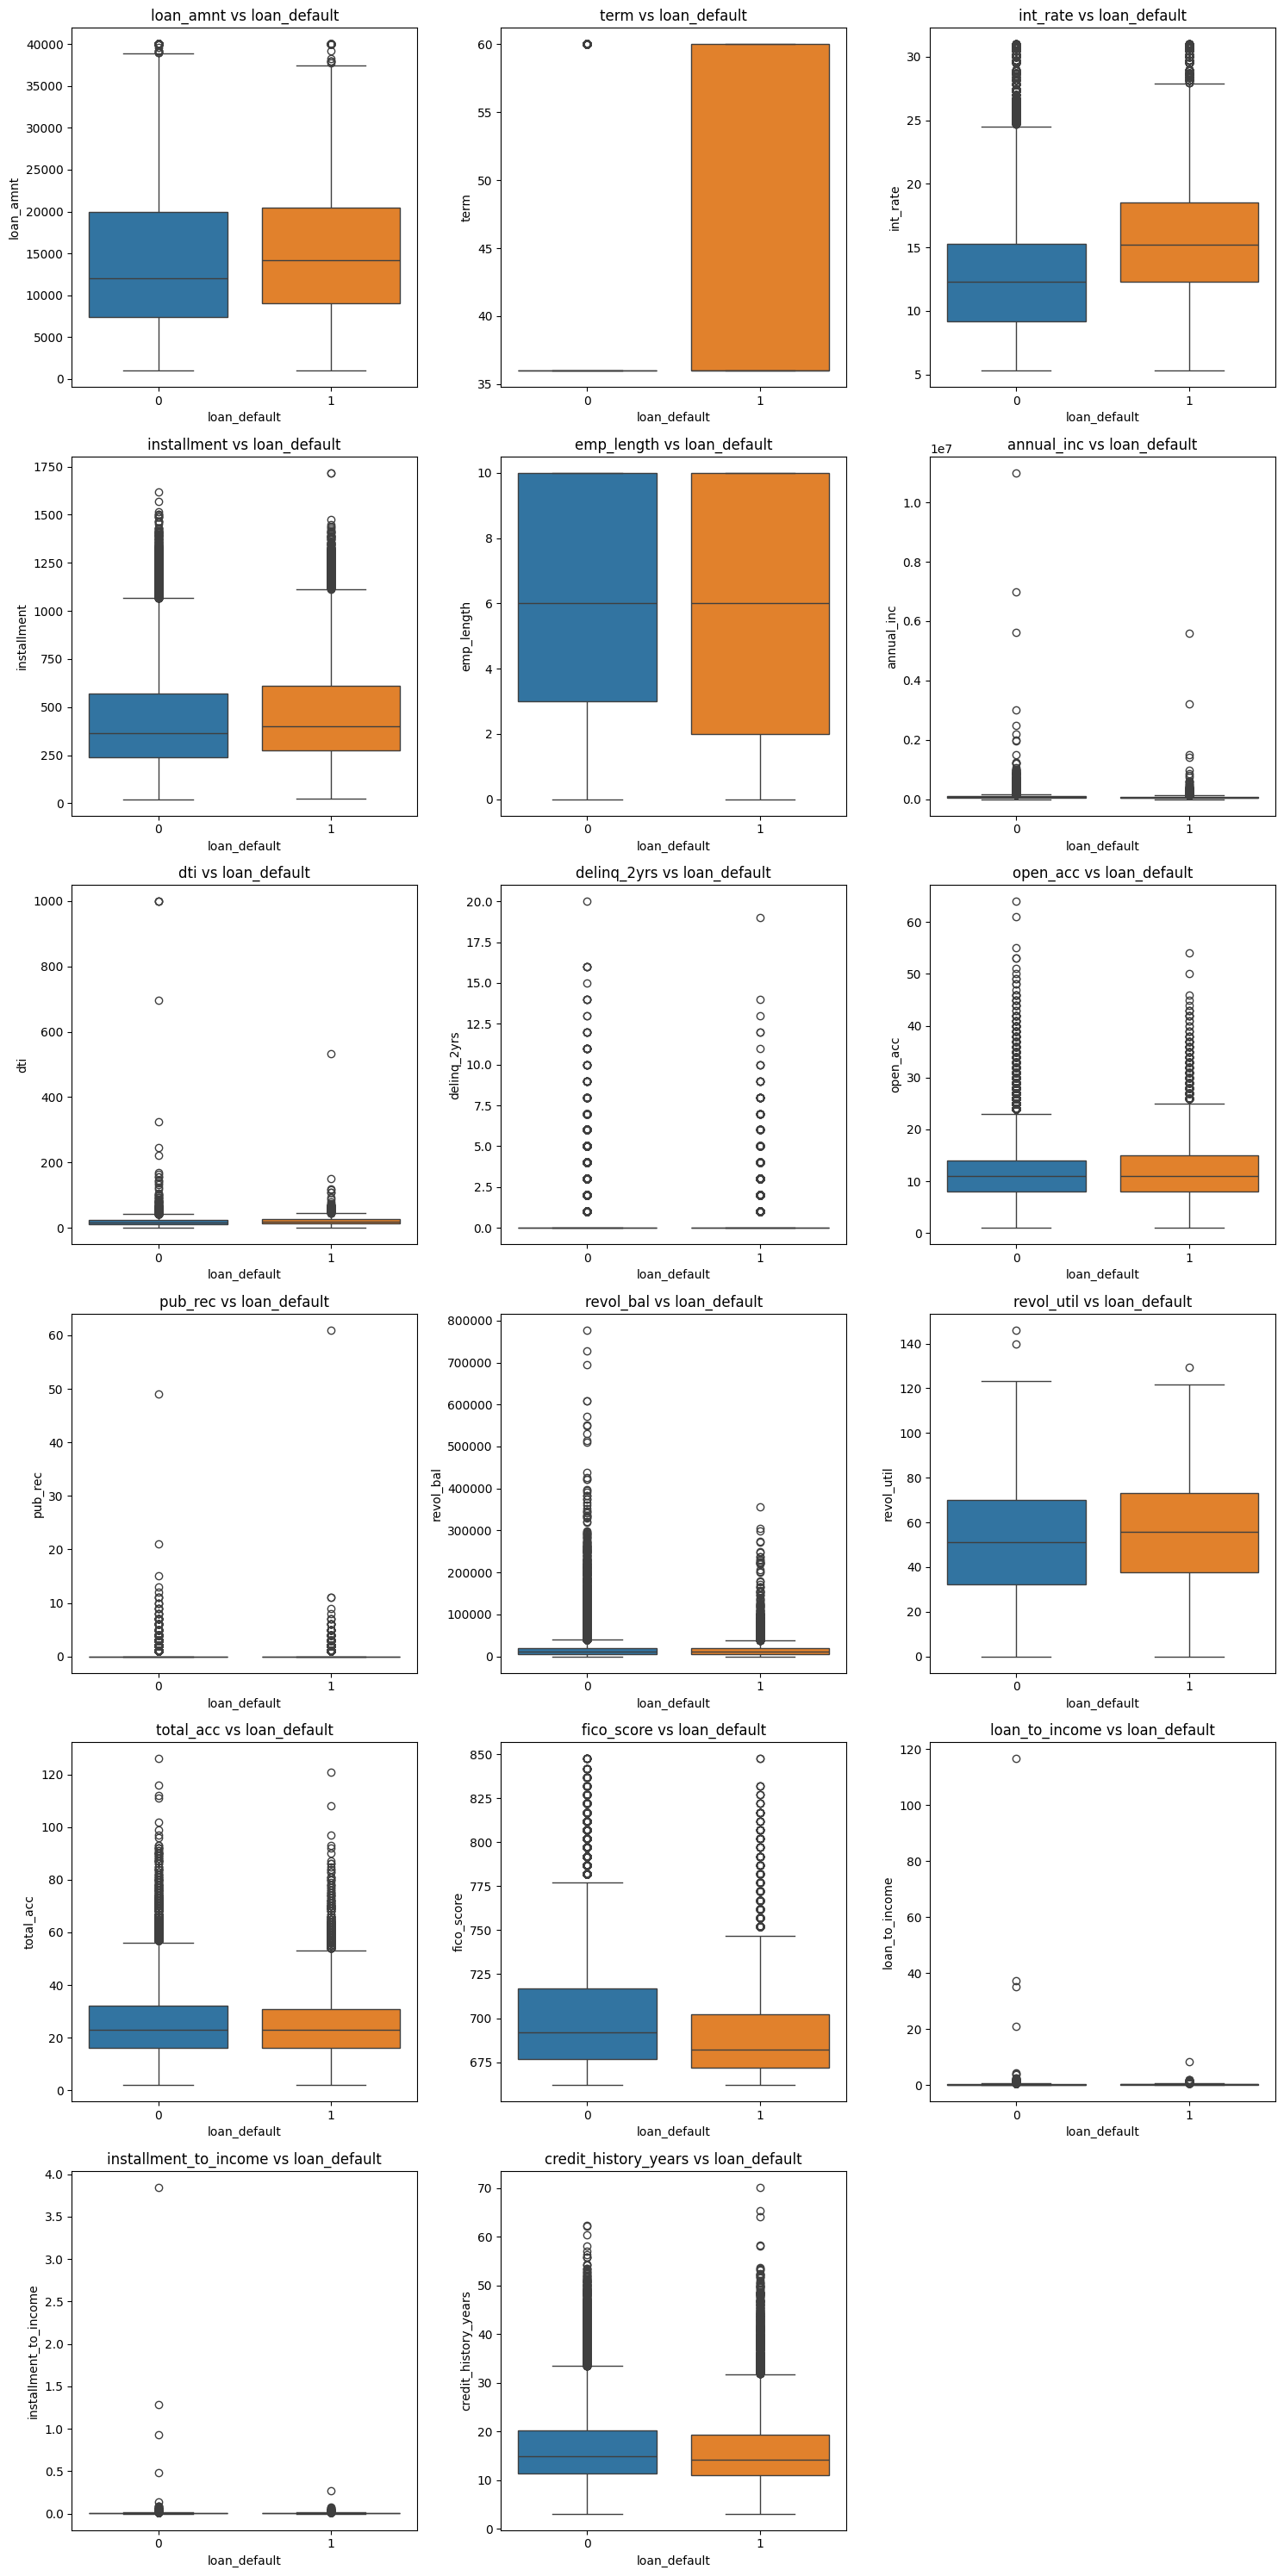

In [15]:
def show_outliers(a, target='loan_default'):

    numerical_cols = a.select_dtypes(include='number').columns
    numerical_cols = numerical_cols.drop(target, errors='ignore')

    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):

        sns.boxplot(
            data=a,
            x=target,
            y=col,
            hue=target,
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel(col)

    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


show_outliers(df)

In [16]:
def count_outliers_by_class(df, target, num_col):

    result = []

    # Total observations
    total_rows = len(df)

    # Total observations in each class
    class_counts = df[target].value_counts()

    for cls in df[target].dropna().unique():

        data = df.loc[df[target] == cls, num_col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Identify outliers
        outlier_mask = (data < lower) | (data > upper)

        outliers = outlier_mask.sum()

        # Total outliers across ALL classes will be calculated later
        result.append({
            'Class': cls,
            'Total': len(data),
            'Class_%_Of_Total': round(
                class_counts[cls] / total_rows * 100, 2
            ),
            'Q1': Q1,
            'Q3': Q3,
            'Lower_Bound': lower,
            'Upper_Bound': upper,
            'Outlier_Range': f'< {lower:.2f} OR > {upper:.2f}',
            'Outliers': outliers,
            'Outlier_%_Within_Class': round(
                outliers / len(data) * 100, 2
            )
        })

    result = pd.DataFrame(result)

    # Total number of outliers across all classes
    total_outliers = result['Outliers'].sum()

    # Percentage of all outliers belonging to each class
    result['Outlier_%_Of_All_Outliers'] = round(
        result['Outliers'] / total_outliers * 100, 2
    )

    return result

In [17]:
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols = numerical_cols.drop('loan_default')

for col in numerical_cols:

    print(f"\n{'='*50}")
    print(f"Feature: {col}")
    print(f"{'='*50}")

    display(
        count_outliers_by_class(
            df,
            'loan_default',
            col
        )
    )


Feature: loan_amnt


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,7375.0,20000.0,-11562.5,38937.5,< -11562.50 OR > 38937.50,275,0.48,79.71
1,1,14439,20.24,9000.0,20500.0,-8250.0,37750.0,< -8250.00 OR > 37750.00,70,0.48,20.29



Feature: term


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,36.0,36.0,36.0,36.0,< 36.00 OR > 36.00,11544,20.29,100.0
1,1,14439,20.24,36.0,60.0,0.0,96.0,< 0.00 OR > 96.00,0,0.00,0.0



Feature: int_rate


...

,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56890,79.76,0.118813,0.277778,-0.119634,0.516225,< -0.12 OR > 0.52,315,0.55,77.02
1,1,14434,20.24,0.153846,0.333333,-0.115385,0.602564,< -0.12 OR > 0.60,94,0.65,22.98



Feature: installment_to_income


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56890,79.76,0.003701,0.008450,-0.003423,0.015574,< -0.00 OR > 0.02,810,1.42,83.76
1,1,14434,20.24,0.004685,0.009889,-0.003120,0.017694,< -0.00 OR > 0.02,157,1.09,16.24



Feature: credit_history_years


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,11.331964,20.167009,-1.920602,33.419576,< -1.92 OR > 33.42,1710,3.00,75.87
1,1,14439,20.24,10.913073,19.252567,-1.596167,31.761807,< -1.60 OR > 31.76,544,3.77,24.13


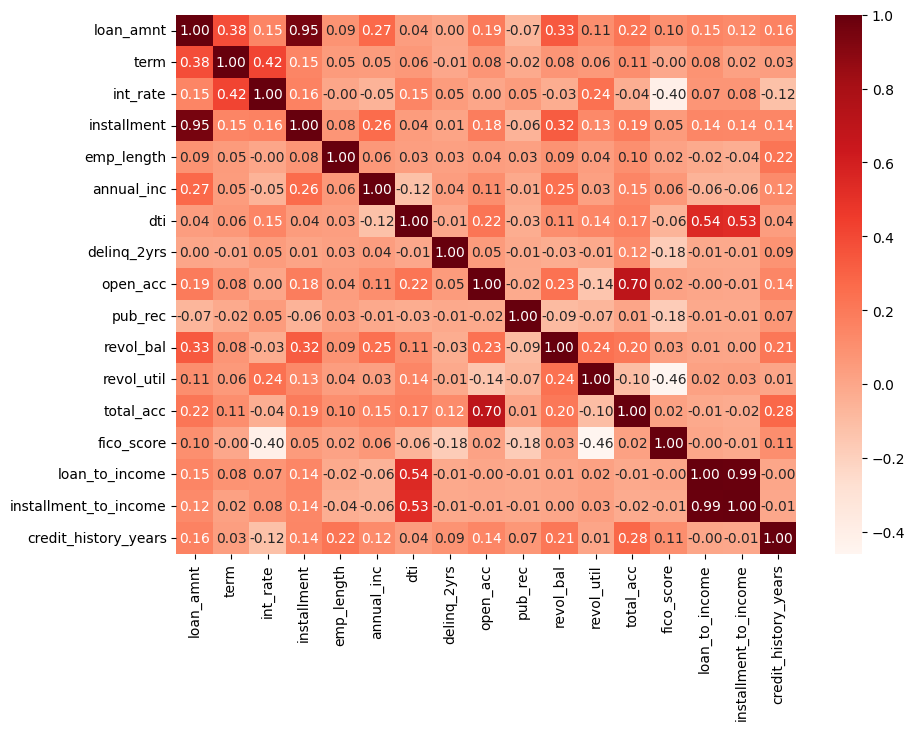

In [18]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.show()

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [21]:
from src.config import (
    PROCESSED_DATA_PATH,
    TARGET,
    TEST_SIZE,
    RANDOM_STATE,
)
from src.preprocessing import OutlierCapper

In [22]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

#===================================================
from sklearn.utils import resample

# -----------------------------
# Downsample training data only
# -----------------------------

train_data = X_train.copy()
train_data[TARGET] = y_train

# Separate majority and minority classes
train_majority = train_data[train_data[TARGET] == 0]
train_minority = train_data[train_data[TARGET] == 1]

print("Before downsampling:")
print(train_data[TARGET].value_counts())

# Downsample class 0
train_majority_downsampled = resample(
    train_majority,
    replace=False,
    n_samples=len(train_minority),
    random_state=RANDOM_STATE
)

# Combine both classes
train_downsampled = pd.concat([
    train_majority_downsampled,
    train_minority
])

# Shuffle
train_downsampled = train_downsampled.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# Separate X and y again
X_train = train_downsampled.drop(columns=[TARGET])
y_train = train_downsampled[TARGET]

print("\nAfter downsampling:")
print(y_train.value_counts())

print("\nTest set - untouched:")
print(y_test.value_counts())


#====================================================


# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# Preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="passthrough"
)


# Models
models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "random_forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "xgboost": XGBClassifier(
        random_state=RANDOM_STATE
        
    )
}


# Train each model
trained_models = {}

Before downsampling:
loan_default
0    45527
1    11551
Name: count, dtype: int64

After downsampling:
loan_default
1    11551
0    11551
Name: count, dtype: int64

Test set - untouched:
loan_default
0    11382
1     2888
Name: count, dtype: int64


In [20]:
from sklearn.metrics import average_precision_score,roc_auc_score,confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report

In [21]:
for name, model in models.items():

    

    pipeline = Pipeline(
        steps=[
            ("outlier_capper", OutlierCapper()),
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_train_prob = pipeline.predict_proba(X_train)[:, 1]

    # Metrics
    train_accuracy = pipeline.score(X_train, y_train)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_prob)

    # Print results
    print(f"{name}")
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1       : {train_f1:.4f}")
    print(f"ROC-AUC  : {train_roc_auc:.4f}")
    print("-" * 40)

c:\Data Science\DataScience_Projects\lending_club_default_risk_project\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic_regression
Accuracy : 0.6541
Precision: 0.6491
Recall   : 0.6709
F1       : 0.6598
ROC-AUC  : 0.7103
----------------------------------------
random_forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000
----------------------------------------
gradient_boosting
Accuracy : 0.6725
Precision: 0.6713
Recall   : 0.6760
F1       : 0.6736
ROC-AUC  : 0.7350
----------------------------------------
xgboost
Accuracy : 0.8491
Precision: 0.8489
Recall   : 0.8493
F1       : 0.8491
ROC-AUC  : 0.9294
----------------------------------------


In [22]:
results = []

for name, model in trained_models.items():

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6453     0.3204  0.6714 0.4338   0.7084  0.3784
      random_forest    0.6374     0.3100  0.6461 0.4190   0.6961  0.3515
  gradient_boosting    0.6476     0.3195  0.6562 0.4298   0.7086  0.3736
            xgboost    0.6290     0.3023  0.6368 0.4099   0.6803  0.3404


In [19]:
'''
xgb = trained_models["xgboost"]

y_test_pred = xgb.predict(X_test)
y_test_prob = xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_test_pred))
'''

'\nxgb = trained_models["xgboost"]\n\ny_test_pred = xgb.predict(X_test)\ny_test_prob = xgb.predict_proba(X_test)[:, 1]\n\nprint("\nXGBoost Confusion Matrix:")\nprint(confusion_matrix(y_test, y_test_pred))\n\nprint("\nXGBoost Classification Report:")\nprint(classification_report(y_test, y_test_pred))\n'

In [23]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Train/test split only - NO downsampling here.
# We tune with class_weight="balanced" instead, so we keep all the
# training data available to RandomizedSearchCV's CV folds.
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance (untouched):")
print(y_test.value_counts(normalize=True))

# Preprocessing (same as before)
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Stratified CV - preserves class ratio in every fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train class balance:
loan_default
0    0.797628
1    0.202372
Name: proportion, dtype: float64

Test class balance (untouched):
loan_default
0    0.797617
1    0.202383
Name: proportion, dtype: float64


In [24]:
# NOTE: step name must exactly match the prefix used in each param grid
# below (LR__, RF__, GBM__, XGB__) - that's what RandomizedSearchCV uses
# to route hyperparameters to the right step.

pipelines = {
    "logistic_regression": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("LR", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000))
    ]),
    "random_forest": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("RF", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "gradient_boosting": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("GBM", GradientBoostingClassifier(random_state=RANDOM_STATE))
        # NOTE: GradientBoostingClassifier has no class_weight param.
        # We pass sample_weight at .fit() time instead - see fit_params below.
    ]),
    "xgboost": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("XGB", XGBClassifier(
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

# Your existing param grids (unchanged, prefixes already match step names above)
param_range = [2, 3, 4, 5, 6]
param_range_fl = [0.6, 0.8, 1.0]
n_estimators = [50, 100, 150, 200, 300]
learning_rates = [0.01, 0.03, 0.05, 0.1]

param_grids = {
    "logistic_regression": {
        "LR__penalty": ["l1", "l2"],
        "LR__C": [0.01, 0.1, 0.5, 1.0, 10.0],
        "LR__solver": ["liblinear"]
    },
    "random_forest": {
        "RF__min_samples_leaf": [1, 2, 3, 5, 10],
        "RF__max_depth": param_range,
        "RF__min_samples_split": [2, 3, 4, 5, 10, 20],
        "RF__n_estimators": n_estimators,
        "RF__max_features": ["sqrt", "log2"]
    },
    "gradient_boosting": {
        "GBM__learning_rate": learning_rates,
        "GBM__n_estimators": n_estimators,
        "GBM__max_depth": param_range,
        "GBM__min_samples_split": [2, 5, 10, 20],
        "GBM__min_samples_leaf": [1, 2, 5, 10],
        "GBM__subsample": param_range_fl
    },
    "xgboost": {
        "XGB__learning_rate": learning_rates,
        "XGB__max_depth": param_range,
        "XGB__min_child_weight": [1, 2, 3, 5],
        "XGB__subsample": param_range_fl,
        "XGB__colsample_bytree": param_range_fl,
        "XGB__n_estimators": n_estimators
    },
}

In [26]:
# scoring="f1" balances precision/recall on the positive (default) class.
# Swap to "average_precision" (PR-AUC) if you want an even imbalance-robust
# metric, or "recall" if you're willing to trade precision for catching
# more defaulters.
SCORING = "f1"
N_ITER = 5

search_results = {}
best_estimators = {}

for name, pipeline in pipelines.items():
    print(f"\n{'='*60}\nTuning: {name}\n{'='*60}")

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    # GradientBoostingClassifier has no class_weight - pass sample_weight
    # through the pipeline's fit() instead, routed to the "GBM" step.
    fit_params = {}
    if name == "gradient_boosting":
        class_counts = y_train.value_counts()
        weight_map = {0: 1.0, 1: class_counts[0] / class_counts[1]}
        fit_params["GBM__sample_weight"] = y_train.map(weight_map)

    search.fit(X_train, y_train, **fit_params)

    search_results[name] = search
    best_estimators[name] = search.best_estimator_

    print(f"Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")


Tuning: logistic_regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.4289
Best params: {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}

Tuning: random_forest
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.4255
Best params: {'RF__n_estimators': 300, 'RF__min_samples_split': 5, 'RF__min_samples_leaf': 5, 'RF__max_features': 'log2', 'RF__max_depth': 6}

Tuning: gradient_boosting
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.4275
Best params: {'GBM__subsample': 0.8, 'GBM__n_estimators': 150, 'GBM__min_samples_split': 20, 'GBM__min_samples_leaf': 5, 'GBM__max_depth': 2, 'GBM__learning_rate': 0.1}

Tuning: xgboost
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.4312
Best params: {'XGB__subsample': 0.6, 'XGB__n_estimators': 200, 'XGB__min_child_weight': 5, 'XGB__max_depth': 4, 'XGB__learning_rate': 0.05, 'XGB__colsample_bytree': 1.0}


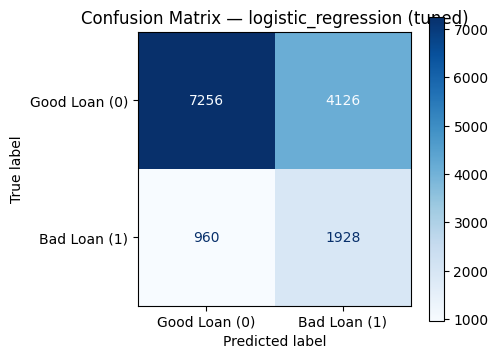

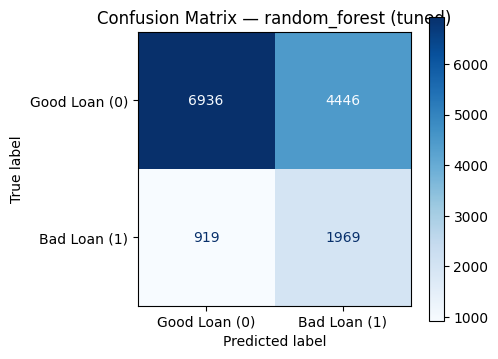

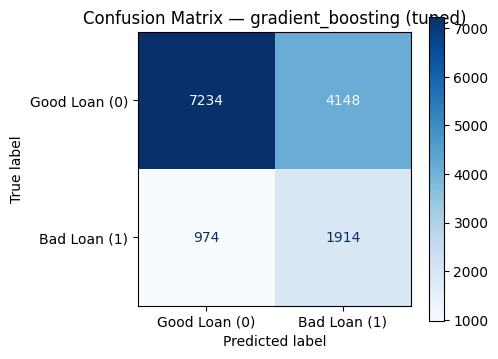

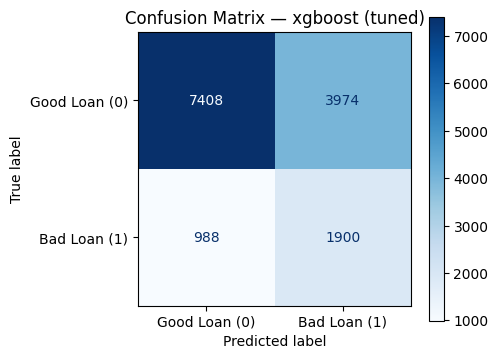


Tuned model results (test set):
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6436     0.3185  0.6676 0.4312   0.7071  0.3766
      random_forest    0.6240     0.3069  0.6818 0.4233   0.7010  0.3615
  gradient_boosting    0.6411     0.3157  0.6627 0.4277   0.7072  0.3727
            xgboost    0.6523     0.3235  0.6579 0.4337   0.7095  0.3752


In [27]:
CLASS_NAMES = ["Good Loan (0)", "Bad Loan (1)"]

tuned_results = []

for name, model in best_estimators.items():
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_test_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix — {name} (tuned)")
    plt.tight_layout()
    plt.show()

tuned_results_df = pd.DataFrame(tuned_results)
print("\nTuned model results (test set):")
print(tuned_results_df.round(4).to_string(index=False))

In [5]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'application_type', 'fico_score',
       'loan_to_income', 'installment_to_income', 'credit_history_years',
       'loan_default'],
      dtype='object')

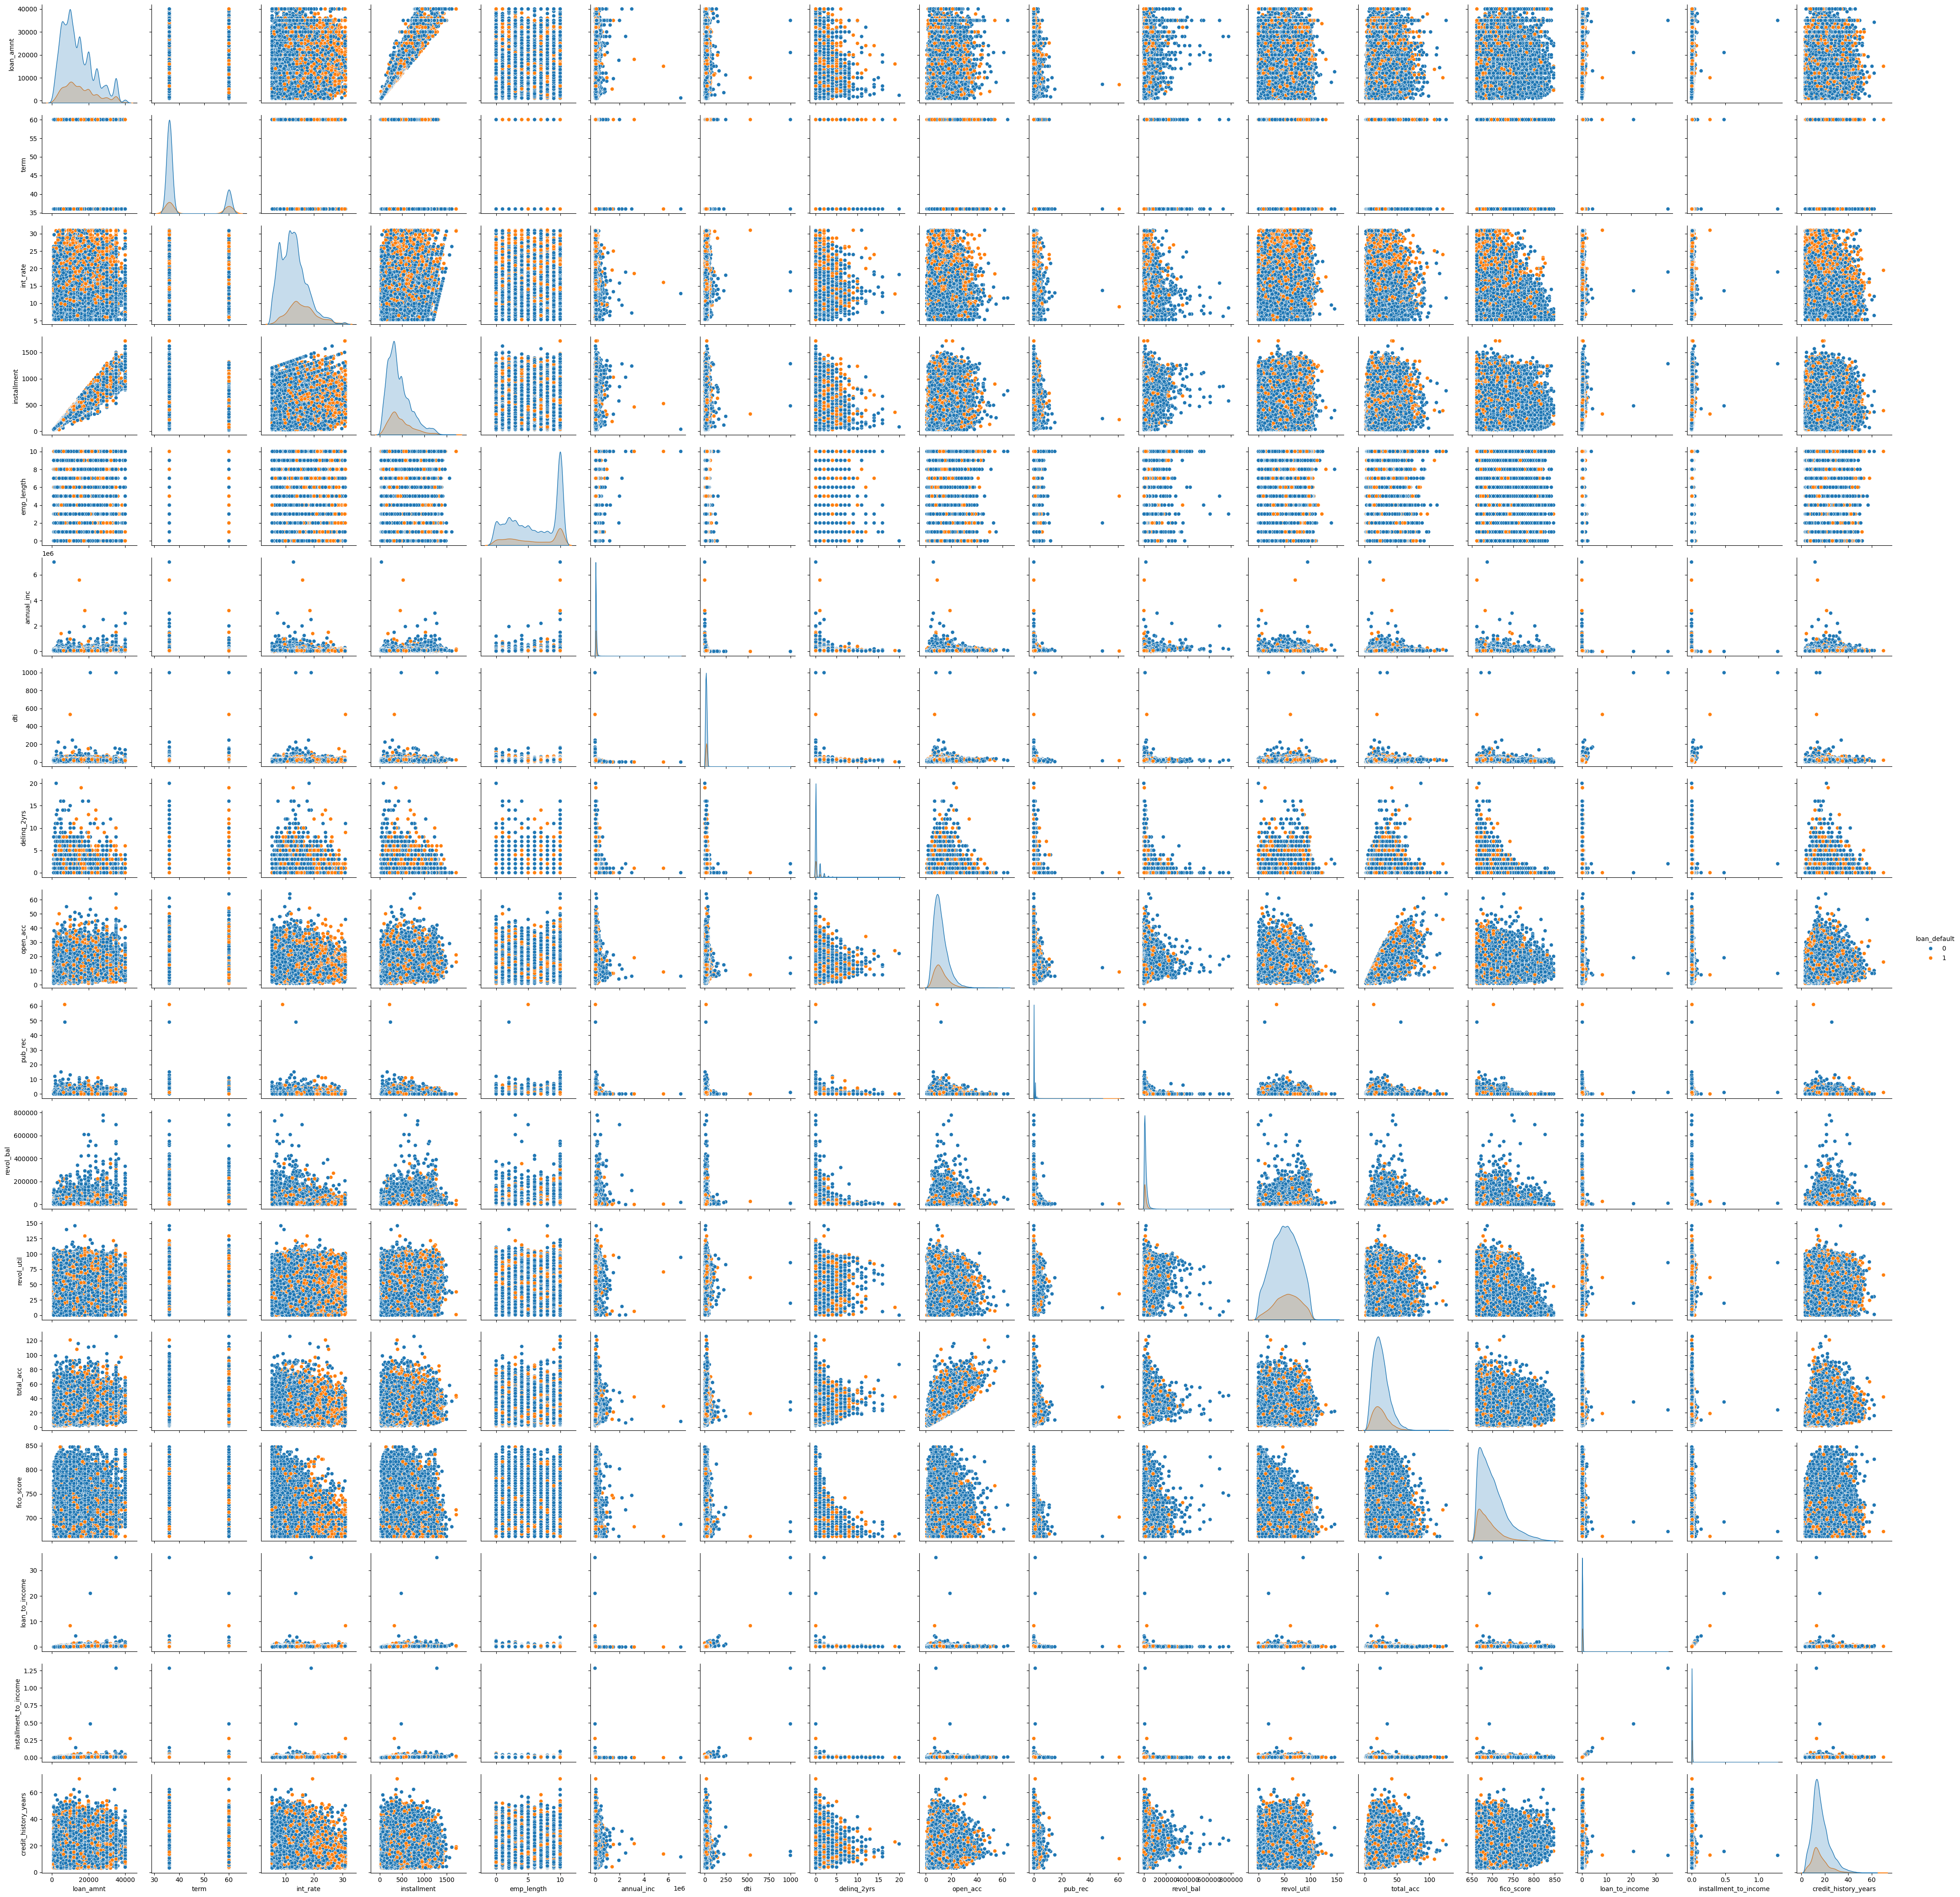

In [23]:
sns.pairplot(train_data, hue='loan_default')

In [24]:
t = ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
       'loan_status', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4',
       'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3',
       'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2',
       'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1',
       'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5',
       'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4',
       'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3',
       'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2',
       'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5',
       'verification_status_Source Verified', 'verification_status_Verified',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_house',
       'purpose_major_purchase', 'purpose_medical', 'purpose_moving',
       'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'initial_list_status_w',
       'application_type_INDIVIDUAL', 'application_type_JOINT',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'zip_code_05113', 'zip_code_11650', 'zip_code_22690', 'zip_code_29597',
       'zip_code_30723', 'zip_code_48052', 'zip_code_70466', 'zip_code_86630',
       'zip_code_93700']

In [30]:
k = [ 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4',
       'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3',
       'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2',
       'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1',
       'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5',
       'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4',
       'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3',
       'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2',
       'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5',
       'verification_status_Source Verified', 'verification_status_Verified',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_house',
       'purpose_major_purchase', 'purpose_medical', 'purpose_moving',
       'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'initial_list_status_w',
       'application_type_INDIVIDUAL', 'application_type_JOINT',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'zip_code_05113', 'zip_code_11650', 'zip_code_22690', 'zip_code_29597',
       'zip_code_30723', 'zip_code_48052', 'zip_code_70466', 'zip_code_86630',
       'zip_code_93700']

K=len(k)

In [31]:
T=len(t)

In [32]:
T-K

15

In [33]:
from src.config import RAW_DATA_PATH

In [34]:
df1 = pd.read_csv(RAW_DATA_PATH)

C:\Users\souradip\AppData\Local\Temp\ipykernel_12364\3558014655.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(RAW_DATA_PATH)


In [ ]:
import kagglehub
husainsb_lendingclub_issued_loans_path = kagglehub.dataset_download('husainsb/lendingclub-issued-loans')
wordsforthewise_lending_club_path = kagglehub.dataset_download('wordsforthewise/lending-club')
janiobachmann_lending_club_first_dataset_path = kagglehub.dataset_download('janiobachmann/lending-club-first-dataset')
jeandedieunyandwi_lending_club_dataset_path = kagglehub.dataset_download('jeandedieunyandwi/lending-club-dataset')
ethon0426_lending_club_20072020q1_path = kagglehub.dataset_download('ethon0426/lending-club-20072020q1')
adarshsng_lending_club_loan_data_csv_path = kagglehub.dataset_download('adarshsng/lending-club-loan-data-csv')

print('Data source import complete.')

In [35]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'application_type', 'fico_score',
       'loan_to_income', 'installment_to_income', 'credit_history_years',
       'loan_default'],
      dtype='object')

In [36]:
df.shape

(71348, 24)